### Event Study Models

* TWFE
* Gardner
* Sun & Abraham
* Callaway & Sant'Anna
* Borusyak, Jaravel & Spiess


In [1]:
# Pacotes
import numpy as np
import pandas as pd
import plotnine as p
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.iolib.summary2 import summary_col

In [2]:
# Carregar a base de dados
df = pd.read_stata("https://github.com/Daniel-Uhr/data/raw/main/bacon_example.dta")

In [3]:
# Outcome (Suicide Mortality)
df['Y'] = df['asmrs']
# Treatment D (Staggered treatment adoption)
df['D'] = df['post']
# Covariáveis - pcinc asmrh cases
df['X1'] = df['pcinc']
df['X2'] = df['asmrh']
df['X3'] = df['cases']

# Identificação do painel
df['year'] = df['year'].astype(int)
df['id'] = df['stfips'].astype('category').cat.codes + 1

# Relative time (Tempo relativo até o tratamento - ocorre somente para os tratados)
df['reltime'] = df['year'] - df['_nfd']
# colocar valor zero caso tenha dados faltantes
df['reltime'] = df['reltime'].fillna(0)
# garantir que 'reltime' seja um inteiro
df['reltime'] = df['reltime'].astype(int)

# Generates a new column called 'ct' containing the numerics version of calendar time 'year'
df['ct'] = df['year'] - 1964

# Vamos criar a variável de grupo (cohoort) e G (Callaway-SantAnna)
df['cohort'] = df['_nfd'] - 1965
df['G']=df['_nfd']

# control group
df['treated'] = 0
df.loc[df['_nfd'] > 0, 'treated'] = 1
df['control_group'] = 1
df.loc[df['treated'] == 1, 'control_group'] = 0

# Criar uma coluna que identifica os indivíduos que nunca foram tratados (nevertreated)
df['nevertreated'] = 0
df.loc[df['treated'] == 0, 'nevertreated'] = 1

# Criar uma coluna que identifica os indivíduos que sempre foram tratados (alwaystreated) Deve ser 1 para todos os anos após o tratamento D
df['mean_treat'] = df.groupby('id')['D'].transform('mean')
# Criar os sempre tratados
df['alwaystreated'] = 0
df.loc[(df['mean_treat'] == 1), 'alwaystreated'] = 1

### TWFE Event Study

In [4]:
# Regressão controlando os efeitos fixos id e ano, com erro padrão robusto à heterocedasticidade.
reg1 = smf.wls('Y ~ D + C(id) + C(year)', data=df).fit(cov_type='HC1')
#print(reg1.summary())
reg1.summary2().tables[1].loc[['Intercept', 'D'], :].round(4)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,42.5023,2.4121,17.6206,0.0000,37.7747,47.2299
D,-3.0799,1.2677,-2.4295,0.0151,-5.5646,-0.5953


In [5]:
# TWFE naive - Dynamic Difference-in-Differences

# Especificar a fórmula com a categoria 0 de reltime como referência diretamente
formula = 'Y ~ C(reltime, Treatment(reference=0)) + C(id) + C(year)'

# Ajustar o modelo
twfe = smf.ols(formula, data=df).fit(cov_type='HC1')

# Extraindo os resultados
beta = pd.DataFrame(twfe.params, columns=['coef'])  # Coeficientes estimados
ci = twfe.conf_int()  # Intervalos de confiança

# Renomear as colunas do intervalo de confiança para consistência
ci.columns = ['lower', 'upper']

# Combinar os resultados em um único DataFrame
est = beta.join(ci)

# Manter apenas os coeficientes relativos ao efeito de reltime
est = est.reset_index(drop=False)
est = est[est['index'].str.contains('C(reltime, Treatment(reference=0))[T.', regex=False)]  

# Clean the coefficient names for readability
est['index'] = est['index'].str.replace('C(reltime, Treatment(reference=0))[T.', '', regex=False)  # Remove the prefix
est['index'] = est['index'].str.replace(']', '', regex=False)         # Remove closing brackets

# Set the index to the cleaned relative time
est = est.set_index('index')

est = est.reset_index()  # Transforma o índice em uma coluna
est['index'] = pd.to_numeric(est['index'])  # Converte para numérico

est = est.sort_values('index')  # Agora ordenará corretamente
# Certifique-se de que o índice é numérico para ordenação
est.index = pd.to_numeric(est.index)

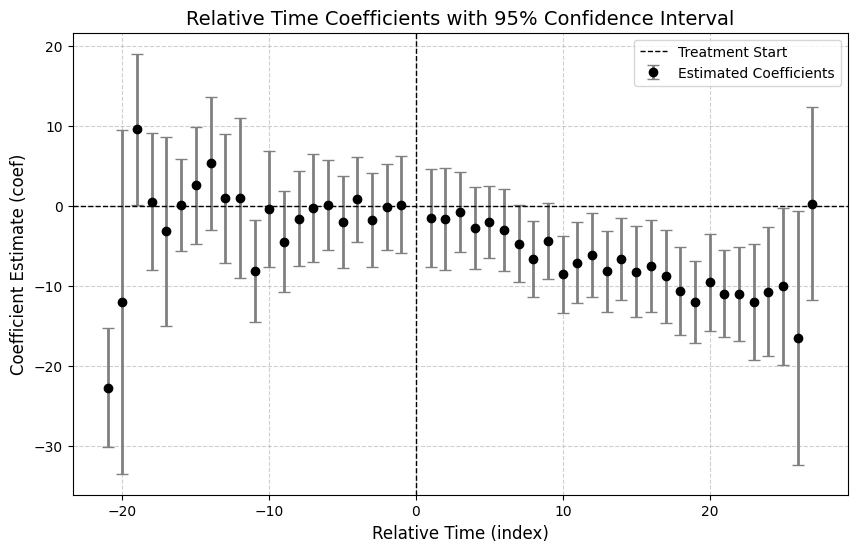

In [6]:
import matplotlib.pyplot as plt

# Configurar o gráfico
plt.figure(figsize=(10, 6))

# Plotar os coeficientes com barras de erro
plt.errorbar(
    est['index'],  # Valores do eixo x
    est['coef'],   # Valores do eixo y (coeficientes)
    yerr=[est['coef'] - est['lower'], est['upper'] - est['coef']],  # Barras de erro
    fmt='o', color='black', ecolor='gray', elinewidth=2, capsize=4, label='Estimated Coefficients'
)

# Adicionar uma linha horizontal no valor 0 para referência
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Adicionar linha vertical para o início do tratamento em zero
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Treatment Start')

# Adicionar título e rótulos
plt.title('Relative Time Coefficients with 95% Confidence Interval', fontsize=14)
plt.xlabel('Relative Time (index)', fontsize=12)
plt.ylabel('Coefficient Estimate (coef)', fontsize=12)

# Adicionar grade e legenda
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Exibir o gráfico
plt.show()

### Gardner Event Study

In [7]:
from pyfixest.estimation import feols
import pyfixest as pf
from pyfixest.report.utils import rename_event_study_coefs

In [8]:
# Converte para categoria para gerar dummies automaticamente (efeitos fixos)
df['id'] = df['id'].astype('category')
df['year'] = df['year'].astype('category')

In [24]:
twfe_model = feols("Y ~ D | year + id", data=df)
print(twfe_model.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+id
Inference:  CRV1
Observations:  1617

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |     -3.080 |        1.187 |    -2.594 |      0.014 | -5.498 |  -0.662 |
---
RMSE: 10.731 R2: 0.701 R2 Within: 0.005 
None


In [25]:
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype(float)
df['G'] = pd.to_numeric(df['G'], errors='coerce').astype(float)

# Substitui os valores ausentes de tratamento por infinito
df['G'] = df['G'].fillna(np.inf)

# 1. Corrigir rel_year: nunca tratados ficam como NaN
df['rel_year'] = df['year'] - df['G']
df.loc[df['D'] == 0, 'rel_year'] = np.nan  # nunca tratados não entram no event-study

In [27]:
fit_did2s = pf.did2s(
    data=df,
    yname="Y", 
    treatment="D",
    first_stage="~ 0 |  id + year",
    second_stage="~i(rel_year, ref= 0)",
    cluster="id",
)

ValueError: operands could not be broadcast together with shapes (1107,28) (1617,1) 

In [11]:
# Estima o modelo de Gardner (did2s) com covariáveis
fit_gardner = pf.did2s(
    data=df,
    yname="Y",                     # variável dependente
    treatment="D",                # dummy de tratamento
    first_stage="~ | id + year",  # controles + efeitos fixos
    second_stage="~ D",           # variável de interesse
    cluster="id"              # erro padrão clusterizado
)
print(fit_gardner.summary())

AttributeError: Not a valid formula provided.

In [12]:
import pandas as pd
import statsmodels.formula.api as smf

# Passo 1: Restringir a observações não tratadas ou pré-tratamento
# Usar reltime < 0 para unidades tratadas e todas as observações para unidades nunca tratadas
untreated = df[(df['reltime'] < 0) | (df['g'] == 0)].copy()

# Primeira etapa: Estimar efeitos fixos
first_stage = smf.ols("Y ~ C(id) + C(year)", data=untreated).fit()

# Prever Y(0) para todas as observações
df["y0_pred"] = first_stage.predict(df)

# Calcular resultado residualizado: Y - Y(0)
df["y_star"] = df["Y"] - df["y0_pred"]

# Passo 2: Regressão de estudo de evento
second_stage = smf.ols("y_star ~ C(reltime, Treatment(reference=0))", 
                       data=df).fit(cov_type="cluster", cov_kwds={'groups': df['id']})

# Exibir resultados
print(second_stage.summary())

KeyError: 'g'

In [13]:
data = df.copy()

In [14]:
# Filtragem dos dados
# Vamos criar identificadores estaduais
data['id'] = data['stfips'].astype('category').cat.codes + 1

# Outcome (Suicide Mortality)
data['Y'] = data['asmrs']
# Treatment
data['D'] = data['post']
# Covariáveis - pcinc asmrh cases
data['X1'] = data['pcinc']
data['X2'] = data['asmrh']
data['X3'] = data['cases']

# Vamos criar a variável de grupo G
data['G']=data['_nfd']

In [15]:
# Criar uma variável de tempo até o ano do início do tratamento (Tempo em relação ao início do evento)
data['timeToTreat'] = data['year'] - data['_nfd']
data['timeToTreat'].describe()

count    1188.000000
mean        6.416667
std        10.162403
min       -21.000000
25%        -2.000000
50%         6.000000
75%        15.000000
max        27.000000
Name: timeToTreat, dtype: float64

In [2]:
from pyfixest.estimation import feols
import pyfixest as pf
from pyfixest.report.utils import rename_event_study_coefs

In [16]:
# O pacote precisa entender a estrutura de painel dos dados. Precisamos ajustar a variável year para int (inteiro)
# Criando clones
data['year1'] = data['year']
data['id1'] = data['id']
data['year1'] = data['year'].astype(int)

# Definir os indices (estrutura de painel)
data.set_index(['id1', 'year1'], inplace=True)

In [17]:
att_gt = ATTgt(data=data, cohort_name="G")

NameError: name 'ATTgt' is not defined

In [ ]:
att_gt.aggregate("event")

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from libpysal.weights import lag_spatial
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from pyfixest.estimation import feols
import pyfixest as pf
from pyfixest.report.utils import rename_event_study_coefs

# CS ML
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV

In [5]:
# === Etapa 1: Carregar shapefile dos municípios do Brasil ===
shapefile_path = "C:/Users/danie/OneDrive/Data/Shape_BR_2022/BR_Municipios_2024.shp"
gdf = gpd.read_file(shapefile_path)

# Selecionar e renomear colunas principais
gdf = gdf[['CD_MUN', 'NM_MUN', 'SIGLA_UF', 'geometry']].copy()
gdf = gdf.rename(columns={'CD_MUN': 'codmun', 'NM_MUN': 'municipio', 'SIGLA_UF': 'uf'})

# Calcular centroides
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x

# Mapeamento de UFs para regiões
regiao_dict = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# Adiciona a coluna de região
gdf['regiao'] = gdf['uf'].map(regiao_dict)


# === Etapa 2: Simular covariáveis iniciais e suas tendências ===
np.random.seed(42)
n_mun = gdf.shape[0]
gdf['X1'] = np.random.normal(0, 1, n_mun)
gdf['X2'] = np.random.normal(0, 1, n_mun)
gdf['X3'] = np.random.normal(0, 1, n_mun)

# Aumentar os valores das variáveis X em 20% para Sul e Sudeste
regioes_ricas = ['Sul', 'Sudeste']
mask_ricas = gdf['regiao'].isin(regioes_ricas)
gdf.loc[mask_ricas, ['X1', 'X2', 'X3']] *= 1.2

# Tendência de crescimento heterogênea
gdf['X1_trend'] = np.random.normal(0.01, 0.005, n_mun)
gdf['X2_trend'] = np.random.normal(0.02, 0.007, n_mun)
gdf['X3_trend'] = np.random.normal(0.015, 0.004, n_mun)


# === Etapa 3: Expandir painel 2000–2024 com evolução dos X ===
years = list(range(2000, 2025))
panel = pd.DataFrame(
    [(row.codmun, row.municipio, row.uf,
      row.X1 + (year - 2000) * row.X1_trend,
      row.X2 + (year - 2000) * row.X2_trend,
      row.X3 + (year - 2000) * row.X3_trend,
      row.lat, row.lon, year)
     for idx, row in gdf.iterrows() for year in years],
    columns=['codmun', 'municipio', 'uf', 'X1', 'X2', 'X3', 'lat', 'lon', 'year']
)


# === Etapa 4: Atribuir tratamento a 10% dos municípios (7% via características, 3% aleatório) ===
np.random.seed(42)

# Passo 1: calcular escore de propensão ao tratamento
gdf['prop_score'] = 1 / (1 + np.exp(-(1.5 * gdf['X1'] + 1.0 * gdf['X2'] + 0.5 * gdf['X3'])))

# Passo 2: ordenar por escore e selecionar top 7%
n_7 = int(0.07 * n_mun)
treated_by_score = gdf.sort_values(by='prop_score', ascending=False).head(n_7)['codmun'].tolist()

# Passo 3: selecionar 3% aleatoriamente entre os restantes
remaining = gdf[~gdf['codmun'].isin(treated_by_score)]
n_3 = int(0.03 * n_mun)
treated_random = np.random.choice(remaining['codmun'], size=n_3, replace=False).tolist()

# Passo 4: juntar tratados
treated_muns = treated_by_score + treated_random
gdf['treated'] = gdf['codmun'].isin(treated_muns).astype(int)

# Passo 5: definir anos de tratamento entre 2005 e 2020
treatment_years = {mun: np.random.randint(2005, 2021) for mun in treated_muns}
panel['treat_year'] = panel['codmun'].map(treatment_years)
panel['D'] = ((panel['treat_year'].notnull()) & (panel['year'] >= panel['treat_year'])).astype(int)

# Calcular anos desde tratamento (efeito dinâmico)
panel['years_treated'] = (panel['year'] - panel['treat_year']).clip(lower=0)
panel['years_treated'] = panel['years_treated'].where(panel['D'] == 1, 0)
panel['treatment_effect'] = panel['years_treated'].clip(upper=3)


# === Etapa 5: Matriz de vizinhança espacial ===
w = Queen.from_dataframe(gdf)
W_sparse = w.full()[0]

# === Etapa 6: Recalcular índice socioeconômico por ano (com interações complexas) ===
panel['X_index'] = 0.0
for year in years:
    df_year = panel.loc[panel['year'] == year, ['X1', 'X2', 'X3']]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_year)
    X1s, X2s, X3s = X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2]
    
    X_index_new = (
        0.5 * (X1s + X2s + X3s) +
        0.3 * (X1s * X2s) +
        0.2 * (X1s**2 * X2s * X3s)
    )
    panel.loc[panel['year'] == year, 'X_index'] = X_index_new

# === Etapa 7: Calcular variável de spillover binário ===
panel['WD'] = 0.0

for year in years:
    D_year = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(D_year['D']).fillna(0).values.reshape(-1, 1)  # respeita a ordem
    WD_vector = W_sparse @ D_vector
    panel.loc[panel['year'] == year, 'WD'] = WD_vector.flatten()

# Variável binária: 1 se o município tem ao menos um vizinho tratado no ano
panel['WD1'] = (panel['WD'] > 0).astype(int)

# === Etapa 7.1: Criar variável de spillover acumulado (WD_cumulativo) ===
panel['WD_cumulativo'] = 0

for cod in panel['codmun'].unique():
    df_mun = panel[panel['codmun'] == cod].sort_values("year")
    wd_vals = df_mun["WD1"].values

    # Primeiro ano com vizinho tratado
    first_year_with_wd = np.where(wd_vals > 0)[0]

    if len(first_year_with_wd) > 0:
        start = first_year_with_wd[0]
        wd_cum_vals = np.zeros_like(wd_vals)
        wd_cum_vals[start:] = 1
        panel.loc[df_mun.index, "WD_cumulativo"] = wd_cum_vals


# === Etapa 8: Gerar variável de resultado Y com spillover apenas nos vizinhos não tratados ===
np.random.seed(42)
alpha_dict = dict(zip(gdf['codmun'], np.random.normal(0, 0.2, n_mun)))
panel['alpha_i'] = panel['codmun'].map(alpha_dict)
panel['lambda_t'] = (panel['year'] - 2000) * 0.01
panel['epsilon'] = np.random.normal(0, 0.3, panel.shape[0])

# Coeficientes
beta = 1.5   # efeito direto do tratamento
gamma = 0.8  # efeito do spillover nos vizinhos não tratados

# Geração de Y
panel['Y'] = (
    2 +
    0.6 * panel['X1'] +
    0.4 * panel['X2'] +
    0.2 * panel['X3'] +
    beta * panel['treatment_effect'] +
    gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
    panel['alpha_i'] +
    panel['lambda_t'] +
    panel['epsilon']
)
